# **Análisis Exploratorio y Modelado Predictivo de Enfermedades Cardíacas mediante MLOps**

## **1. Contexto** 

El conjunto de datos utilizado corresponde a ``Heart Failure Prediction Dataset`` (2021), disponible públicamente en Kaggle que contiene registros de información de pacientes que han o no padecido una insuficiencia cardíaca. Es un dataset pequeño, que cuenta con unas ``918`` observaciones, lo que nos permite desarrollar un flujo completo de *Machine Learning Operations* (MLOps) de manera local, utilizando varias herramientas y monitoreo.

Este dataset reune información de distintos registros clínicos de pacientes que han sido diagonosticados o no con insuficiencia cardíaca. Entre sus variables incluyen edad, sexo, tipo de dolor del pecho, colesterol, presión sanguínea y otras características asociadas a la salud del paciente. El dataset resulta útil para predecir el riesgo de falla cardíaca.

## **2. Objetivo** 

Desarrollar un modelo de clasificación supervisada binaria que prediga si un paciente está en riesgo de sufrir una falla cardíaca o no, mediante un flujo de trabajo que incluya un ánalisis exploratorio de datos, preprocesamiento, entrenamiento seguro con `Pipelines`, despliegue local, orquestación, integración continua, y monitoreo.

## **3. Propósito del estudio** 

El propósito de este estudio es demostrar cómo un problema real de salud puede abordarse mediante técnicas de aprendizaje automático, construyendo un pipeline de análisis que no solo genere predicciones, sino que también permita comprender la lógica de preparación de datos, justificar las decisiones metodológicas y comparar distintas etapas de implementación.

## **4. Metodología** 

El proyecto se desarrolla siguiendo un flujo de trabajo de MLOps dividido en seis etapas secuenciales, que van desde el análisis de los datos hasta el monitoreo del modelo en producción.
Se parte de una estructura de carpetas modular que organiza claramente cada componente del proyecto: notebooks, API, contenedores, orquestación y flujos de CI/CD. Esta separación facilita la lectura y el mantenimiento del código a lo largo de todas las etapas.

El análisis exploratorio permite entender la naturaleza del dataset, identificar valores atípicos y detectar posibles fuentes de fuga de datos. A partir de estos hallazgos se toman las decisiones de preprocesamiento, como la imputación de valores faltantes en la variable Cholesterol y la codificación de variables categóricas. Para ilustrar el impacto del data leakage, se introduce una variable artificial correlacionada con la variable objetivo y se comparan los resultados obtenidos con y sin su presencia.

Con los datos listos, se entrena un conjunto de clasificadores utilizando Pipeline y GridSearchCV, asegurando que ninguna transformación acceda a información del conjunto de prueba durante el entrenamiento. Los modelos se comparan mediante AUC y Accuracy, y el mejor se exporta para su despliegue.

Finalmente, el modelo se sirve a través de una API REST con FastAPI, se conteneriza con Docker y se despliega localmente usando Kubernetes. Para garantizar la calidad del código en cada cambio, se configura un flujo de integración continua con GitHub Actions. El proceso cierra con el monitoreo de deriva de datos mediante Evidently, que permite detectar cambios en la distribución de los datos en producción.

## **5. Carga y estructura del dataset**

Para la realización del análisis exploratorio se utiliza el lenguaje de programación Python, con librerías dedicadas al análisis, visualización, entrenamiento y limpiezas. 

En este caso se importa el conjunto de datos desde un archivo en formato CSV, permitiendo su almacenamiento en una estructura de tipo DataFrame que facilita su manipulación y el análisis de variables. Esta etapa nos permite verificar la lectura correcta del archivo, reconocer la estructura del DataFrame y preparar el entorno para las fases posteriores del análisis.

### **5.1 Importación de librerías y carga del dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import seaborn as sns
from sklearn.impute import SimpleImputer
from scipy.stats import pointbiserialr
import math
import warnings
warnings.filterwarnings("ignore")
import matplotlib.ticker as mticker
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

#Colores a utilizar
morado = "#e63946"
aqua = "#457b9d"
colors = [aqua, morado]

df = pd.read_csv("data/heart.csv")

### **5.2 Visualización inicial de los datos**

In [2]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


### **5.3 Dimensiones**

In [4]:
df.shape

(918, 12)

In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

El dataset original cuenta con 918 registros (filas) y 12 variables (columnas), lo cual lo posiciona como un dataset pequeño. Esto permitira a la hora de entrenar mucho más rapidez; sin embargo, no es tan robusto, por lo tanto, no podrá tener una buena generalización.

Las 12 columnan abarcan información esencial del paciente incluyendo información demográfica (edad, sexo), síntomas y condiciones clínicas (tipo de dolor en el pecho), medidas fisiológicas (colesterol, presión arterial, glucosa, etc) y resultados de pruebas médicas (electrocardiograma), y finalmente, la variable objetivo que indica la presencia o ausencia de enfermedad cardíaca. 

### **5.4 Estructura**

In [6]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.dtypes.value_counts()

int64      6
object     5
float64    1
Name: count, dtype: int64

Se evidencia que las variables del dataset se distribuyen entre **7 variables numéricas (int64 y float64)** y **5 variables categóricas (objetct)**, lo que indica una distribución mixta. Donde encontramos variables binarias como `FastingBS` que indica si el nivel de azúcar en sangre en ayunas es alto, y la variable objetivo (``HeartDisease``), en este caso, aunque son tratadas y clasificadas como enteros, es adecuado mencionar que son categóricas dicótomicas. 

Por otro lado, la salida de `df.info()` permite identificar que todas las columnas tienen el mismo nivel de completitud. Lo que nos da entender que no es necesario emplear técnicas de imputación. 

Finalmente, esta revisión nos permite comprender la estructura del conjunto de datos, facilitando la correcta selección de técnicas y preprocesamiento en las etapas posteriores.

## **6. Limpieza y Verificación de Calidad de los Datos**

Antes de proceder con el análisis descriptivo y las visualizaciones es importante verificar la calidad de los datos con los que se trabaja. Esta etapa permite identificar incosistencias, valores faltantes, duplicados o errores en el rango de las variables, garantizando que los resultados posteriores sean confiables y correctamente interpretados.

### **6.1 Identificación de valores faltantes**

Como primer paso, identificaremos los valores nulos dentro del dataset.

In [8]:
valores_faltantes = df.isnull().sum()
valores_faltantes_porcentaje = (df.isnull().mean() * 100).round(2)

na_dataframe = pd.DataFrame({
    'Valores Faltantes': valores_faltantes,
    'Porcentaje Faltante (%)': valores_faltantes_porcentaje
}).rename_axis("Variable").reset_index()

na_dataframe

,Variable,Valores Faltantes,Porcentaje Faltante (%)
0,Age,0,0.0
1,Sex,0,0.0
2,ChestPainType,0,0.0
3,RestingBP,0,0.0
4,Cholesterol,0,0.0
5,FastingBS,0,0.0
6,RestingECG,0,0.0
7,MaxHR,0,0.0
8,ExerciseAngina,0,0.0
9,Oldpeak,0,0.0


El análisis de valores faltantes revela a simple vista un patrón homogéneo entre las variables del dataset. Dado que según los resultados, no hay valores nulos dentro de la base de datos, lo que nos indica que no hay que hacer uso de técnicas de imputación. Sabiendo esto, se puede hacer un análisis adecuado sin preoocuparnos en problemas que se pueden dar en el modelado, visualización, gracias a la naturaleza de estos datos. 

### **6.2 Revisión de observaciones duplicadas**

Ahora, identifiquemos si hay observaciones que se repiten:

In [9]:
duplicados = df.duplicated().sum()
duplicados

0

In [10]:
df[df.duplicated()]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease


El dataset no contiene registros duplicados exactos (0 filas duplicadas). Esto era esperable dado que cada fila representa una historia clínica distinta de cada paciente. La ausencia de duplicados garantiza que no se introducirá sesgo por sobrerepresentación de ciertos registros durante el entrenamiento del modelo.

### **6.3 Valores atípicos**

In [11]:
def resumen_outliers(df):
    
    resultados = []
    
    # Seleccionar variables numéricas
    vars_num = df.select_dtypes(include=["int64","float64"]).columns
    
    # Excluir target si existe
    vars_num = [col for col in vars_num if col != "HeartDisease"]
    
    for col in vars_num:
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)]
        
        resultados.append({
            "Variable": col,
            "Q1": round(Q1,2),
            "Q3": round(Q3,2),
            "IQR": round(IQR,2),
            "Límite inferior": round(limite_inf,2),
            "Límite superior": round(limite_sup,2),
            "N° Outliers": len(outliers),
            "% Outliers": round(len(outliers)/len(df)*100, 2)
        })
    
    return (
        pd.DataFrame(resultados)
        .sort_values("% Outliers", ascending=False)
        .reset_index(drop=True)
    )

tabla_outliers = resumen_outliers(df)
tabla_outliers



,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,N° Outliers,% Outliers
0,FastingBS,0.00,0.0,0.00,0.00,0.00,214,23.31
1,Cholesterol,173.25,267.0,93.75,32.62,407.62,183,19.93
2,RestingBP,120.00,140.0,20.00,90.00,170.00,28,3.05
3,Oldpeak,0.00,1.5,1.50,-2.25,3.75,16,1.74
4,MaxHR,120.00,156.0,36.00,66.00,210.00,2,0.22
5,Age,47.00,60.0,13.00,27.50,79.50,0,0.00


La detección de los atípicos se realizó sobre las 7 variables numéricas del dataset, aplicando el criterio del rango intercuartílico (IQR): se considera atípico todo valor por debajo de $Q_1 − 1.5 \cdot IQR$ o por encima de $Q_3 + 1.5 \cdot IQR$.

Los resultados revelaron una distribución fuertemente asimétrica:

- La variable con mayor proporción de outliers es ``FastingBS`` con un 23.31% (214 observaciones). Esta característica indica si el nivel de azúcar en sangre en ayunas es alto, Sin embargo, es importante tener en cuenta que se trata de una variable dicotómica (0 y 1). Debido a la naturaleza de esta, es su rango intercuartilico es 0, lo que provoca que el criterio del IQR clasifique como outlier a todos los valores distintos de 0, es decir, aquellos casos en los que el nivel de azúcar en ayunas alto, por lo tanto, no se considera un problema de outliers. Finalmente, estos valores no corresponden a observaciones extremas, sino a una de las categorías válidas de la variable, por lo que no se consideran verdaderos outliers ni representan un problema en los datos.

- La variable ``Cholesterol`` presenta una proporción considerada de valores atípicos (19.93). Esto puede deberse por la presencia de pacientes con niveles elevados de colesteros, que usualmente coinciden con la población que sufre de problemas cardiovasculares. No obstante, habría que analizar más detalladamente para ver si estos observaciones válidas o posibles errores en los datos.

- Las variables restantes (``RestingBP``, ``Oldpeak``, ``MaxHR`` y ``Age``) presentan una proporción de outliers inferior al 5%, por lo que no se consideran lo suficientemente significativas como para requerir un tratamiento específico. 

En general, es importante evaluar los valores atípicos identificados, especialmente para la variable ``Cholesterol``, ya que aunque hay modelos que son robustos a estos valores, algoritmos como la regresión logística pueden verse afectados, generando estimaciones y resultados sesgados si no se tratan adecuadamente.

## **7. Análisis de valores faltantes, outliers y preparación inicial del dataset**

Una vez verificada la calidad general del dataset, se procede a indagar más a fondo sobre esas observaciones atípicas, para ver si algunas corresponden a valores faltantes reemplazados por 0. En esta fase, se decidira que técnica aplicar para tratar a los datos faltantes, ya sea por eliminación o por imputación, para posteriormente hacerlo en el preprocesamiento. Y de esa manera, dejaremos listo el dataset para el modelado. Este proceso, lo podemos dividir:

- **Análisis de valores atípicos:** verificaremos los datos atípicos de la variable colesterol, tratando de identificar patrones o valores extremadamente raros. Y mediante eso, se decidira que técnica aplicar. 

- **Eliminación por *data leakage*:** se excluyen (si hay) variables generadas después de haber sido diagonosticado con una enfermedad cardíaca. 

Finalmente, se aplican transformaciones específicas sobre variables con formatos no estándar para convertirlas a representaciones numéricas utilizables por el modelo.

### **7.1 Análisis de datos atípicos en la variable ``Cholesterol``**

Examinamos más a fondo las filas que contienen los valores atípicos de ``Cholesterol``.

In [12]:
Q1 = df["Cholesterol"].quantile(0.25)
Q3 = df["Cholesterol"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_colesterol = df[
    (df["Cholesterol"] < limite_inferior) | 
    (df["Cholesterol"] > limite_superior)
]

outliers_colesterol

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
28,53,F,ATA,113,468,0,Normal,127,N,0.0,Up,0
30,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat,1
69,44,M,ASY,150,412,0,Normal,170,N,0.0,Up,0
76,32,M,ASY,118,529,0,Normal,130,N,0.0,Flat,1
103,40,M,ASY,120,466,1,Normal,152,Y,1.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
535,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat,1
536,62,M,NAP,133,0,1,ST,119,Y,1.2,Flat,1
616,67,F,NAP,115,564,0,LVH,160,N,1.6,Flat,0
667,65,F,NAP,140,417,1,LVH,157,N,0.8,Up,0


De acuerdo a lo anterior, hay varios registros de paciente con colesterol en 0, lo cual indica presencia de valores atípicos. Filtremos para ver cuantos ceros hay:

In [13]:
colesterol_0 = df[df["Cholesterol"] == 0]
colesterol_0.shape

(172, 12)

Es decir, de las 183 observaciones, 172 (93%) corresponden a cuando el colesterol es 0, que es un error puesto que no es humanamente posible. Dado que hay muchas filas con este número, podemos inferir que la razón por la que no hay valores faltantes es porque fueron reemplazados por 0, y estos son una parte de los valores que son considerados como atípicos. Procederemos a filtrar las 11 observaciones que faltan:

In [14]:
colesterol_otro = df[df["Cholesterol"] > 450]
colesterol_otro

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
28,53,F,ATA,113,468,0,Normal,127,N,0.0,Up,0
30,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat,1
76,32,M,ASY,118,529,0,Normal,130,N,0.0,Flat,1
103,40,M,ASY,120,466,1,Normal,152,Y,1.0,Flat,1
149,54,M,ASY,130,603,1,Normal,125,Y,1.0,Flat,1
250,44,M,ASY,135,491,0,Normal,135,N,0.0,Flat,1
496,58,M,ASY,132,458,1,Normal,69,N,1.0,Down,0
616,67,F,NAP,115,564,0,LVH,160,N,1.6,Flat,0


In [15]:
colesterol_otro = df[(df["Cholesterol"] > 0) & (df["Cholesterol"] < 110)]
colesterol_otro

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
78,52,M,ATA,140,100,0,Normal,138,Y,0.0,Up,0
98,56,M,ASY,120,85,0,Normal,140,N,0.0,Up,0
444,56,M,ASY,120,100,0,Normal,120,Y,1.5,Flat,1


Según las dos tablas anteriores, dado que hay valores altos como 603, o 564, procedemos a ignorarlos dado que aunque son raros, sí puede haber casos en el que el colesterol llegue a puntos extremos, además, solo se tratan de 8 observaciones. Ahora probaremos varios enfoques para determinar que hacemos con los outliers.

#### **7.1.1 Técnicas para outliers**

Primero, vamos a analizar que pasa con la distribución cuando se eliminan esas filas con colesterol 0:

In [16]:
df_copia = df[df["Cholesterol"] != 0].copy()
df_copia.shape

(746, 12)

Ya eliminadas, procedemos a comparar la distribución de ambas:

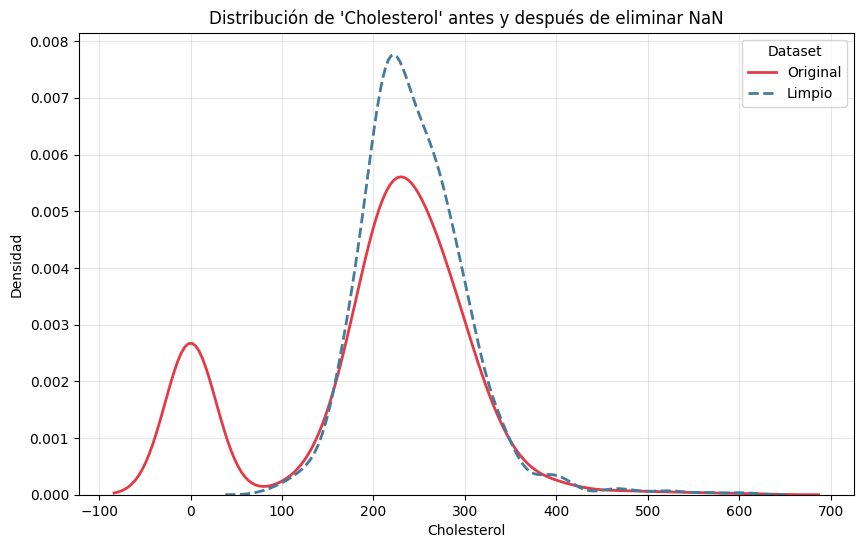

In [17]:
# Ignorar warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Crear gráfico de densidad
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Cholesterol'], label='Original', linewidth=2, color=morado)
sns.kdeplot(df_copia['Cholesterol'], label='Limpio', linewidth=2, linestyle='--', color=aqua)

plt.title("Distribución de 'Cholesterol' antes y después de eliminar NaN")
plt.xlabel("Cholesterol")
plt.ylabel("Densidad")
plt.legend(title="Dataset")
plt.grid(alpha=0.3)
plt.show()

A simple vista, no parece haber un cambio significativo en la distribución. Es claro que al eliminar las observaciones cuyo colesterol era 0, el pico que se ve el dataset original es debido a la concentración de ceros que había que en la base de datos. Sin embargo, aparte de eso, las dos curvas se comportan de manera semejante, siendo el pico del dataset limpio más alto, dado que la mayoría de valores ahora se concentran en los rangos normales del colesterol, mientras que en el original se repartía entre 0 y los normales. Ambos siguen teniendo unos pocos valores mayores a 500.

In [18]:
# PRUEBA KS 
from scipy.stats import ks_2samp

stat, p_value = ks_2samp(
    df[df['Cholesterol'] > 0]['Cholesterol'], 
    df_copia['Cholesterol']
)

print("Prueba Kolmogorov-Smirnov (KS) para 'Cholesterol' ")
print("Estadístico KS:", stat)
print("Valor p:", p_value)
if p_value < 0.05:
    print("Hay diferencias significativas entre las dos distribuciones.")
else:
    print("No hay evidencia significativa de que las distribuciones sean diferentes.")

Prueba Kolmogorov-Smirnov (KS) para 'Cholesterol' 
Estadístico KS: 0.0
Valor p: 1.0
No hay evidencia significativa de que las distribuciones sean diferentes.


Para la prueba estadística, se filtraron los valores que son mayores a 0 puesto que en caso contrario la prueba expresa que sí hay diferencias significativas, y esto puede ser engañoso, dado que claramente en el dataset original hay un pico concentrado en 0, y cuando eliminamos ya no esta, por lo que claramente hay una diferencia significativa por ese lado, por lo que la prueba lo marca incorrectamente. Sin embargo, si filtramos la prueba nos expresa que no hay evidencia significativa de que las distribuciones sean diferentes, lo que concuerda con lo observado en la gráfica. 

**Conclusión**

Finalmente, aunque no se cambia la distribución de la variable ``Cholesterol`` con la eliminación, se suprimen aproximadamente un 18% de los datos totales, lo cual es un número relevante considerando el tamaño del dataset. Por lo que, consideraremos otras técnicas menos intrusivas como `SimpleImputer` o `IterativeImputer` para poder contar con esas filas, sin necesidad de eliminarlas, evitando perder información que puede resultar valiosa a la hora de modelar.

### **7.2 Eliminación de variables con riesgo de data leakage**

La fuga de datos (data-leakage) ocurre cuando se utiliza información no disponible en el momento de la predicción, lo que produce estimaciones optimistas y un bajo rendimiento en producción. Aplicado a este problema, el objetivo es predecir si un paciente está en riesgo de sufrir una falla cardíaca o no, por lo que cualquier variable generada como consecuencia de la estimación debe ser excluida. 

En este caso, todas las características relacionadas al paciente parecen ser previas a la diagnosticación de la condición, por lo que no se identifica data leakage en ninguna variable. No obstante, para evitar fuga de datos durante el preprocesamiento, todas las transformaciones serán ajustadas exclusivamente con los datos de entrenamiento mediante el uso de Pipeline.

### **7.3 Diccionario de datos/Operacionalización de las variables**

In [19]:
descripcion_variables = pd.DataFrame({
    "Variable": [
        "Age",
        "Sex",
        "ChestPainType",
        "RestingBP",
        "Cholesterol",
        "FastingBS",
        "RestingECG",
        "MaxHR",
        "ExerciseAngina",
        "Oldpeak",
        "ST_Slope",
        "HeartDisease"
    ],
    "Rol": [
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Feature",
        "Target"
    ],
    "Tipo": [
        "Numérica continua",
        "Categórica nominal",
        "Categórica nominal",
        "Numérica discreta",
        "Numérica discreta",
        "Binaria",
        "Categórica nominal",
        "Numérica discreta",
        "Categórica nominal",
        "Numérica continua",
        "Categórica nominal",
        "Binaria"
    ],
    "Codificación": [
        "Años",
        "M (Masculine), F (Female)",
        "TA, ATA, NAP, ASY",
        "Milímetros de mercurio (mm Hg)",
        "Milímetros por decilitro (mm/dL)",
        "0 / 1 o dos categorías",
        "Normal, ST, LVH",
        "Latidos por minuto",
        "Y (Yes), N (No)",
        "Valor decimal",
        "Up, Flat, Down",
        "0 = Normal / 1 = Heart Disease "
    ],
    "Descripción": [
        "Edad del paciente",
        "Sexo del paciente",
        "Tipo de dolor en el pecho",
        "Presión arterial en reposo",
        "Nivel de colesterol en sangre",
        "Indica si la glucosa en ayunas es mayor a 120 mg/dL",
        "Resultado del electrocardiograma en reposo",
        "Frecuencia cardíaca máxima alcanzada",
        "Presencia de angina inducida por ejercicio",
        "Depresión del segmento ST durante ejercicio",
        "Pendiente del segmento ST",
        "Indica presencia (1) o ausencia (0) de enfermedad cardíaca"
    ]
})

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

descripcion_variables.style.hide(axis="index")

Variable,Rol,Tipo,Codificación,Descripción
Age,Feature,Numérica continua,Años,Edad del paciente
Sex,Feature,Categórica nominal,"M (Masculine), F (Female)",Sexo del paciente
ChestPainType,Feature,Categórica nominal,"TA, ATA, NAP, ASY",Tipo de dolor en el pecho
RestingBP,Feature,Numérica discreta,Milímetros de mercurio (mm Hg),Presión arterial en reposo
Cholesterol,Feature,Numérica discreta,Milímetros por decilitro (mm/dL),Nivel de colesterol en sangre
FastingBS,Feature,Binaria,0 / 1 o dos categorías,Indica si la glucosa en ayunas es mayor a 120 mg/dL
RestingECG,Feature,Categórica nominal,"Normal, ST, LVH",Resultado del electrocardiograma en reposo
MaxHR,Feature,Numérica discreta,Latidos por minuto,Frecuencia cardíaca máxima alcanzada
ExerciseAngina,Feature,Categórica nominal,"Y (Yes), N (No)",Presencia de angina inducida por ejercicio
Oldpeak,Feature,Numérica continua,Valor decimal,Depresión del segmento ST durante ejercicio


## **8. Análisis exploratorio de datos**

Después de haber inspeccionado de manera general el dataset, procedemos a realizar el análisis exploratorio. Primero, empezaremos con un resumen estadístico.

### **8.1 Resumen estadístico**

In [20]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2


En el caso de las variables categóricas, se nos presenta su número de categorías distintas (`unique`), la categoría más frecuente (`top`) y su frecuencia absoluta (`freq`). En este caso, en la variable `Sex`, predomina la categoría M (Masculine), es decir, 725 pacientes son hombres; `ChestPainType` la categoría más común es ASY indicando que hay una gran parte de pacientes que son asíntomaticos; `RestingECG` con Normal, `ExerciseAgina` con N (No) y `ST_Slope`  con Flat.

En cuanto a las numéricas, el resumen permite identificar medidas de tendencia central, dispersión y rangos de variación. Por ejemplo, la variable `Cholesterol` presenta una media de 198.79 miligramos por decilitro con una desviación estándar de 109.38, con valores concentrados entre 0 y 603, es decir, hay personas con un colesterol de 0 (error que posteriormente será tratado) y de 603 que es un colesterol extremadamente alto. La frecuencia máxima alcanzada muestra una media de 136.80 latidos por minuto con una desvación estándar de 25.36, y valores que oscilan entre 60 y 202, lo cual refleja una variabilidad que va desde lo más sano hasta indicando posibles enfermedades cardíacas.

Por último, la variable objetivo `HeartDisease` presenta una media de 0.55, lo que indica que cerca del 55% de los pacientes presenta una enfermedad cardíaca, mientras que el 45% restante no presentan ninguna. Este resultado nos da entender que existe cierto desbalance entre las clases, sin embargo, no parece ser muy extremo.

### **8.2 Simetría y curtosis**

Ahora, pasaremos a evaluar las distribuciones y sus valores extremos.

In [21]:
numeric_df = df.select_dtypes(include=["number"])

skew_kurt = numeric_df.agg([
    "skew",
    "kurt"
]).round(2)

skew_kurt.index = ["Asimetría", "Curtosis"]

skew_kurt

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Asimetría,-0.20,0.18,-0.61,1.26,-0.14,1.02,-0.22
Curtosis,-0.39,3.27,0.12,-0.40,-0.45,1.20,-1.96


De acuerdo a los resultados podemos destacar:

- `Age` no presenta una asimetría elevada (−0.20), lo que indica que la distribución es aproximadamente simétrica. Al ser ligeramente negativa, la media es marginalmente menor que la mediana, ya que la pequeña cola izquierda jala el promedio hacia los valores más bajos. Su curtosis negativa (−0.39) confirma una distribución platicúrtica, lo que significa que las edades están distribuidas de forma relativamente uniforme, sin una concentración fuerte alrededor de la media y con pocos valores extremos.

- `RestingBP` tampoco muestra una asimetría elevada (0.18), lo que nos da a entender que la distribución es aproximadamente simétrica. Es levemente positiva, indicando que la media es ligeramente mayor que la mediana, sugiriendo una pequeña cola hacia la valores altos de la presión arterial. Su curtosis positiva y pronunciada (3.27) confirma una distribución leptocúrtica, lo que indica que los valores se concentran fuertemente alrededor de la media pero con colas pesadas, es decir, hay pacientes con presiones arteriales inusualmente altas o bajas que aparecen con mayor frecuencia de la que se esperaría en una distribución normal.

- `Cholesterol` evidencia una asimetría negativa moderada (−0.61), lo que refleja una distribución ligeramente asimétrica hacia la izquierda. Como se identificó en análisis previos, los pacientes con colesterol registrado como 0 forman una cola izquierda que jala la media por debajo de la mediana, siendo este el principal factor del sesgo. Por otro lado, la curtosis (0.12) es prácticamente cero, lo que indica una distribución muy cercana a la normal en cuanto a sus extremos, confirmando que los valores atípicos no son especialmente frecuentes.

- `FastingBS` es una variable binaria (0: glucosa en ayuno ≤ 120 mg/dL, 1: glucosa en ayuno > 120 mg/dL). Sus valores (asimetría = 1.26, curtosis = −0.40) reflejan el desbalance entre clases: la clase 0 predomina sobre la clase 1, y al haber dos valores posibles, no puede haber colas pesadas.

- `MaxHR` presenta una asimetría casi inexistente (-0.14) y una curtosis negativa (-0.45), lo que indica que la distribución es relativamente uniforme entre la frecuencia máxima alcanzada, sin concentración marcada en ningun valor.

- `Oldpeak` tiene una asimetría positiva pronunciada (1.02), lo que indica una distribución claramente sesgada a la derecha. Esto refleja que la mayoría de los pacientes tienen valores cercanos a 0, mientras que una minoría con depresiones elevadas forma una cola hacia los valores altos. La curtosis moderada (1.20) confirma una distribución leptocúrtica, donde los valores se concentran fuertemente alrededor de la media con colas más pesadas de lo normal, indicando que los casos con depresiones extremas del segmento ST, aunque son minoritarios, aparecen con mayor frecuencia de la esperada.

- `HeartDisease` al ser una variable binaria, que no esta extremedamente desbalanceada, presenta una leve asimetría negativa (-0.22) y curtosis negativa pronunciada (-1.96), lo que refleja ligeramente la predominancia de la clase 0 (sin enfermedad) con respecto a la clase 1 (con enfermedad), mientras que la curtosis nos sugiere que las clases están relativamente balanceadas.

### **8.3 Análisis de la variable objetivo**

Procederemos a analizar la variable respuesta `HeartDisease`,

In [22]:
# Tabla de frecuencias
freq = df["HeartDisease"].value_counts()
pct  = df["HeartDisease"].value_counts(normalize=True) * 100

tabla_target = pd.DataFrame({
    "Clase": ["Normal (0)", "HeartDisease (1)"],
    "Frecuencia": freq.values,
    "Porcentaje (%)": pct.round(2).values
})
tabla_target

,Clase,Frecuencia,Porcentaje (%)
0,Normal (0),508,55.34
1,HeartDisease (1),410,44.66


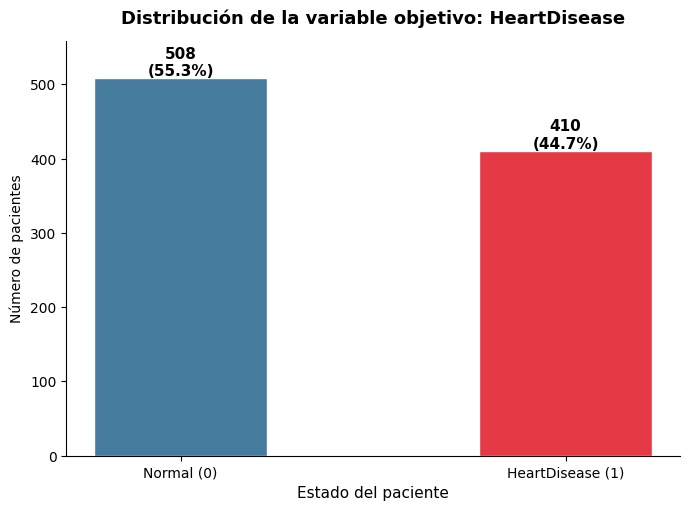

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(["Normal (0)", "HeartDisease (1)"], freq.values,
              color=colors, edgecolor="white", width=0.45)

for bar, val, p in zip(bars, freq.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{val:,}\n({p:.1f}%)", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.set_title("Distribución de la variable objetivo: HeartDisease",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Número de pacientes")
ax.set_ylim(0, freq.max() * 1.10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
ax.set_xlabel("Estado del paciente", fontsize=11)
plt.show()

La distribución de la variable `HeartDisease` presenta un ligero desbalance entre clases: El 55% de los pacientes no presenta enfermedad cardíaca (clase 0/Normal) y el 45% restante sí la presenta (clase 1/HeartDiasease). Esto indica que existe una leve predominancia de la clase 0; sin embargo, no es significativa entre las clases. Esto nos indica que la muestra esta relativamente balanceada, lo cual resulta adecuada para el análisis y la construcción de modelos. Por lo que no parece haber necesidad de aplicar técnicas de desbalanceo. En cambio, primero se optará por evaluar el modelo con métricas como el recall, F1 score, y precision, no solo quedandonos con el accurracy. 

### **8.3 Análisis univariado**

Se analiza la distribución individual de cada una de las variables del dataset respecto a default. Las variables numéricas se analizan mediante histogramas con curva de densidad (KDE), mientras que las variables categóricas se analizan mediante gráficos de barras de frecuencia. En ambos casos se reportan también las estadísticas descriptivas o tablas de frecuencia correspondientes.

#### **8.3.1 Variables numéricas**

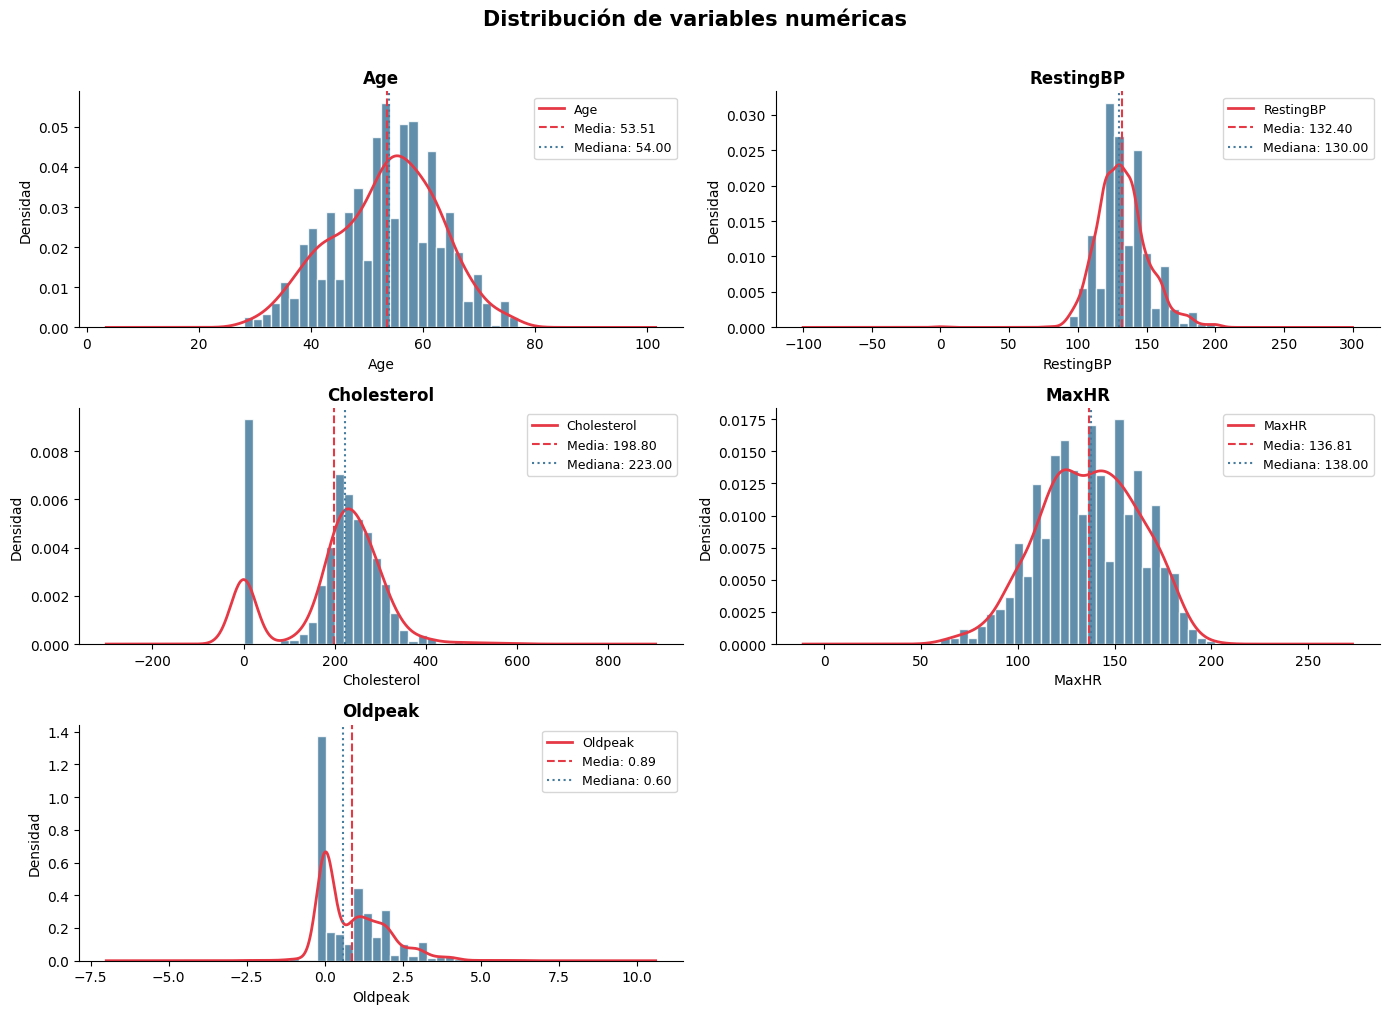

In [24]:
numeric_df = numeric_df.drop(["FastingBS", "HeartDisease"], axis=1)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Distribución de variables numéricas", fontsize=15, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, col in enumerate(numeric_df):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=30, color=aqua, edgecolor="white", alpha=0.85, density=True)
    df[col].dropna().plot(kind="kde", ax=ax, color=morado, linewidth=2)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Densidad")
    ax.spines[["top","right"]].set_visible(False)
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val,   color=morado, linestyle="--", linewidth=1.5, label=f"Media: {mean_val:.2f}")
    ax.axvline(median_val, color=aqua,   linestyle=":",  linewidth=1.5, label=f"Mediana: {median_val:.2f}")
    ax.legend(fontsize=9)
    
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

- ``Age``: la edad presenta una distribución prácticamente simétrica, concentrada entre los 45 y 65 años. La mediana es muy ligeralmente menor a la mediana; pero son muy cercanas, por lo que no hay presencia de sesgo significativo. No se evidencian valores atípos relevantes, lo que sugiere que la edad entre los pacientes está bien distribuida dentro de la muestra.

- `RestingBP`: distribución ligeramente asimetrica positiva, con una mayor concentración de valores entre 11 y 150 milímetros de mercurio. la media supera ligeramente a la mediana, indicando que una fracción de pacientes con presión arterial muy altas que jalan la distribución hacia la derecha. Usualmente, pacientes con presión alterial alta suelen presentar problemas cardíacos, por lo que, puede ser útl para el modelo.

- `Cholesterol`: el colesterol presenta una distribución fuertemente asimétrica negativa, con la gran mayoría de pacientes con colesterol concentrados entre 200 y 350 milímetros por decilitro. Se observa la presencia de un segundo pico, cuyos valores se agrupan en 0, lo cual no es algo plausible dentro del contexto médico. Lo anterior concuerda con lo ya analizado previamente, de manera que, se tendrá que tratar estos valores atípicos antes del modelado.

- `MaxHR`: distribución ligeramente asimétrica positiva, con una gran densidad de frecuencias cardíacas entre 100 y 175 latidos por minuto. La media supera levemente a la mediana, indicando que un pequeño grupo de pacientes presentan una frecuencia cardíaca muy alta que jala la distribución hacia la derecha. No hay valores atípicos significantes.

- `OldPeak`: la depresión del segmento ST presenta una distribución fuertemente asimétrica positiva, con la gran mayoría de paciente concentrados con depresiones bajas del segmento ST, lo que indica que es un buen indicador de que no hay presencia de enfermedad cardíaca. La cola derecha representa pacientes con fuertes depresiones del segmento ST, que pueden ser indicios de enfemedades cardíacas, y esto es lo que jala media hacia la izquierda. 

#### **8.3.2 Variables categóricas**

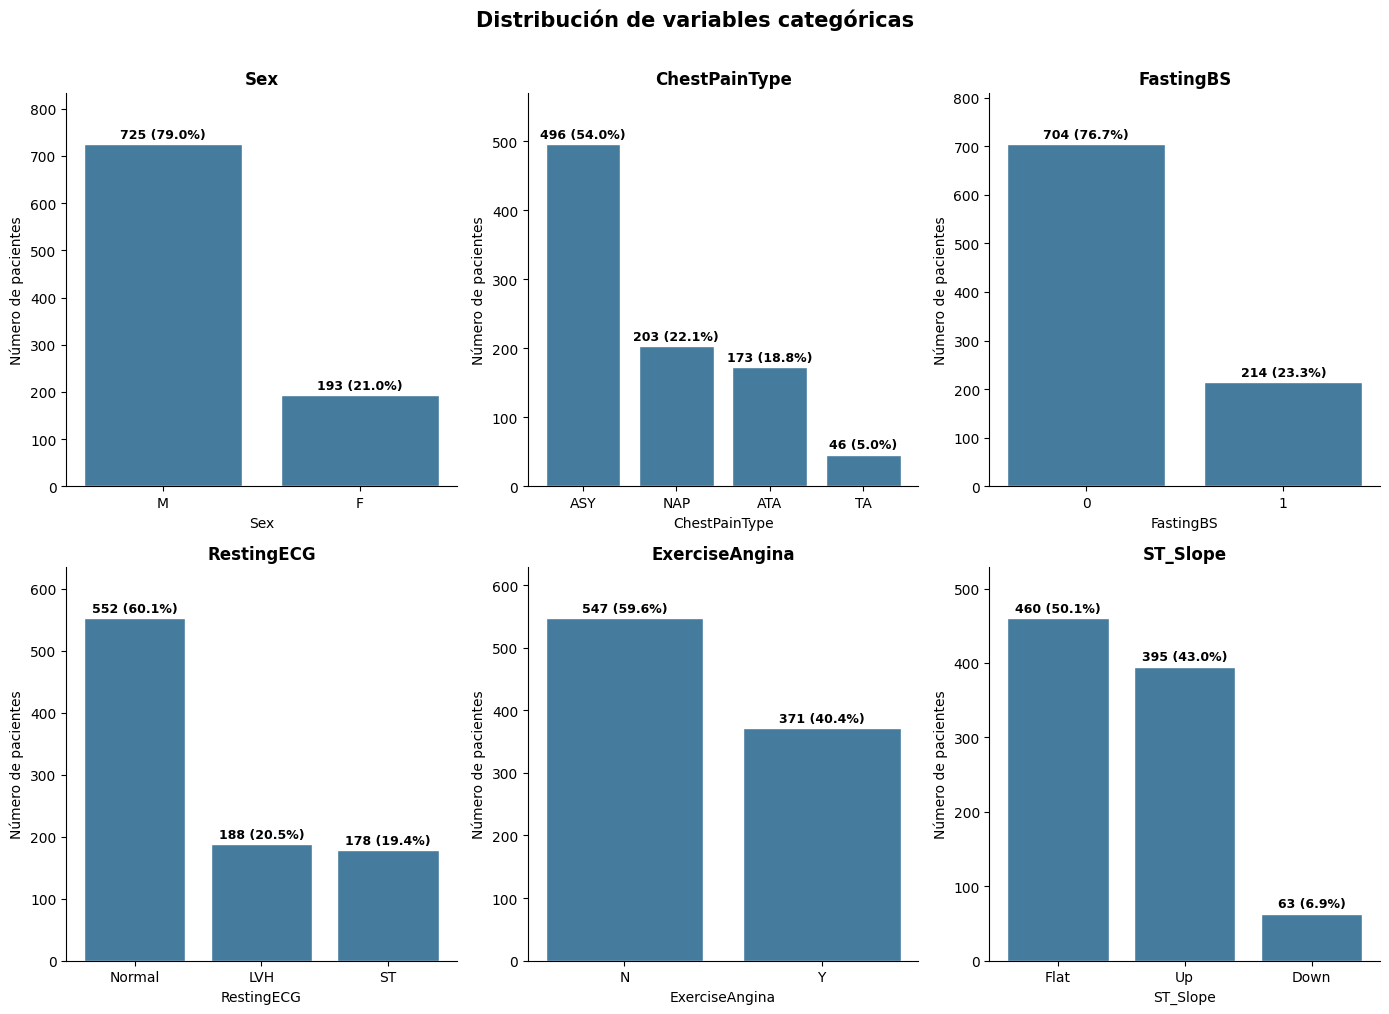

In [25]:
df_copia = df.copy()
df_copia["FastingBS"] = df_copia["FastingBS"].map({
    0: "0",
    1: "1"
})

cat_eda = ["Sex", "ChestPainType", "FastingBS",
           "RestingECG", "ExerciseAngina", "ST_Slope"]

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
fig.suptitle("Distribución de variables categóricas",
             fontsize=15, fontweight="bold", y=1.01)

axes = axes.flatten()

for i, col in enumerate(cat_eda):
    
    ax = axes[i]
    
    freq_cat = df_copia[col].value_counts()
    pct_cat  = df_copia[col].value_counts(normalize=True) * 100

    bars = ax.bar(freq_cat.index, freq_cat.values,
                  color=aqua, edgecolor="white")

    for bar, val, p in zip(bars, freq_cat.values, pct_cat.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + freq_cat.max() * 0.01,
                f"{val:,} ({p:.1f}%)", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Número de pacientes")
    ax.set_xlabel(col)
    ax.set_ylim(0, freq_cat.max() * 1.15)
    ax.spines[["top", "right"]].set_visible(False)


plt.tight_layout()
plt.show()

- `Sex`: la variable sexo presenta una predominancia clara, donde la mayoría de los pacientes son hombres (79%), mientras que las mujeres solo representan el 21%. Esta distribución sugiere una mayor presencia de hombres en el dataset. 

- `ChestPainType`: en el tipo de dolor de pecho, el 54% de los pacientes es asintomático (ASY) al dolor de pecho. Le siguen NAP (22.1%) y ATA (18.8%), mientras que el menos frecuente es TA, el cual afecta solo a un 5% de los pacientes. Este comportamiento nos indica que una gran proporción de pacientes no presenta síntomas típicos de dolor de pecho, lo cual puede dificultar la detección temprana de enfermedades cardíacas.

- `FastingBS`: la glucosa en ayunas, en el 76.7% de los pacientes es menor a 120 miligramos por decilitro, mientras que el 23.3% es mayor a 120. Nos da a entender que la mayoría de los pacientes no presenta una glucosa en ayunas muy alta.

- `RestingECG`: la mayoría de los pacientes presenta resultados normales en el electrocardiograma en reposo (60.1%). Sin embargo, un porcentaje importante muestran anomalías, cuyos resultados fueron catagolados como LVH (20.5%) o ST(19.4%). Lo anterior sugiere que, aunque hay muchos pacientes que no presentan alteraciones, existe un grupo considerable, del casi 40%, con posibles indicadores de problemas cardíacos.

- `ExerciseAngina`: es una variable binaria (N/Y) con marcada asimetría: La categoría N (No) domina ampliamente sobre Y (Yes), indicando que la mayoría de los pacientes no presentan presencia de angina inducida por ejercicio.

- `ST_Slope`: la mayoría de los pacientes presentan una depresión del segmento ST del tipo Flat (50.1%) o del tipo Up (43%), representado juntos el 93.1% de los pacientes. Los pacientes con la categoría Down son una minoría. Esta variable es relevante, dado que parece estar altamente correlacionada con las enfermedades cardíacas.   

### **8.4 Análisis bivariado**

El análisis bivariado examina la relación entre cada variable predictora y la variable objetivo `HeartDisease`. Para las variables numéricas se utilizan boxplots y gráficos de densidad (KDE) comparando la distribución entre ambas clases. Para las variables categóricas se analiza la tasa de enfermedades cardíacas (HeartDisease rate) por categoría, es decir, qué proporción de pacientes dentro de cada categoría terminó con una enfermedad cardíaca.

#### **8.4.1 Variables numéricas**

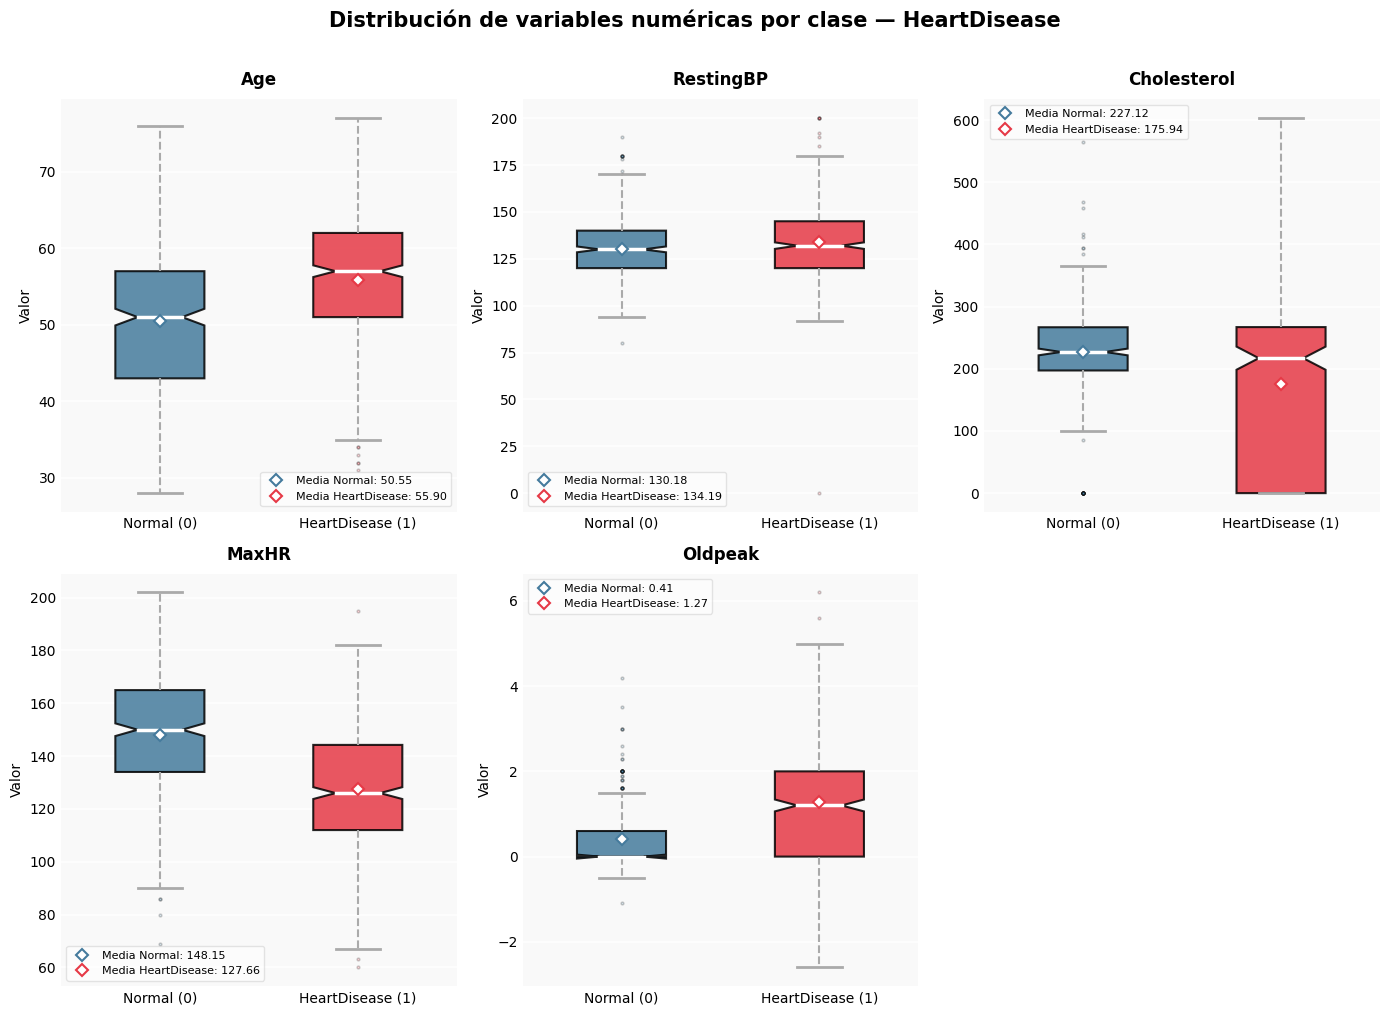

In [26]:
#Boxplots por clase

num_eda = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
fig.suptitle("Distribución de variables numéricas por clase — HeartDisease",
             fontsize=15, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, col in enumerate(num_eda):
    ax = axes[i]
    data0 = df[df["HeartDisease"] == 0][col].dropna()
    data1 = df[df["HeartDisease"] == 1][col].dropna()

    bp = ax.boxplot(
        [data0, data1],
        patch_artist=True,
        widths=0.45,
        notch=True,
        medianprops={"color": "white",  "linewidth": 2.5},
        whiskerprops={"color": "#AAAAAA", "linewidth": 1.5, "linestyle": "--"},
        capprops={"color": "#AAAAAA",   "linewidth": 2},
        flierprops={"marker": "o", "markersize": 2,
                    "alpha": 0.2, "linestyle": "none"},
        boxprops={"linewidth": 1.5}
    )

    bp["boxes"][0].set_facecolor(aqua)
    bp["boxes"][0].set_alpha(0.85)
    bp["fliers"][0].set_markerfacecolor(aqua)

    bp["boxes"][1].set_facecolor(morado)
    bp["boxes"][1].set_alpha(0.85)
    bp["fliers"][1].set_markerfacecolor(morado)

    # Media como punto destacado
    ax.plot(1, data0.mean(), "D", color="white", markersize=6,
            zorder=5, markeredgecolor=aqua,   markeredgewidth=1.5,
            label=f"Media Normal: {data0.mean():.2f}")
    ax.plot(2, data1.mean(), "D", color="white", markersize=6,
            zorder=5, markeredgecolor=morado, markeredgewidth=1.5,
            label=f"Media HeartDisease: {data1.mean():.2f}")

    # Fondo suave alternado
    ax.set_facecolor("#F9F9F9")
    ax.yaxis.grid(True, color="white", linewidth=1.2)
    ax.set_axisbelow(True)

    ax.set_title(col, fontsize=12, fontweight="bold", pad=10)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Normal (0)", "HeartDisease (1)"], fontsize=10)
    ax.set_ylabel("Valor", fontsize=10)
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.tick_params(axis="both", length=0)
    ax.legend(fontsize=8, framealpha=0.5)

fig.delaxes(axes[-1]) #elimina el último gráfico.
plt.tight_layout()
plt.show()

Los diagramas de caja y bigotes nos revelan diferencias entre clases importantes para ver que tan buena capacidad predictiva pueden tener:

- `Age`: es una variable que separa relativamente bien entre clases. Los pacientes que no tienen enfermedad cardíaca (Normal) presentan una media 50.55 años frente a los 55.90 años de los pacientes con enfermedades cardíacas, con una caja desplazada hacia edades más altas y menor dispersión respecto a la otra clase. Esto nos permite inferir que usualmente los pacientes que padecen de condiciones cardiovasculares tienden a ser mayores de 50 años, convirtiendo a `age` un predictor numérico con una capacidad predictiva consistente.

- `RestingBP`: ambas clases presentan una presión arterial en reposo con mediana cercana a 130 milímetros de mercurio y cajas compactas en la parte superior, con ciertos valores atípicos en la parte superior. Las medias son cercanas, lo que indica que esta variable por sí sola no muestra una separación clara. Sin embargo, se observan algunos valores extremos en ambos grupos. Esto sugiere una posible relación débil con la enfermedad.

- `Cholesterol`: el colesterol muestra una alta variabilidad en ambos grupos, con cierta presencia de valores atípicos. El colesterol de los pacientes sin enfermedad cardíaca es (227.12), en promedio, mayor que la de aquellos con la enfermedad; sin embargo, tengamos en cuenta que este valor es debido a la alta cantidad de atípicos que jalan la distribución o la caja hacia valores más bajos en aquellos que padecen esa condición, haciendolo más dispersa. Esto indica que no hay una separación clara entre grupos, pues a simple vista parece solaparse, lo que sugiere que hay una relación débil con la enfermedad. Sin embargo, puede que al tratar estos atípicos, la capacidad predictiva mejore.

- `MaxHR`: es la variable con una de las mayores separaciones entre clases. Los pacientes que no tienen enfermedad cardíaca presentan una mediana cercana a 150 latidos por minutos frente a los aproximados 123 latidos por minutos en los pacientes que sí presentaron enfermedades cardíacas, con una caja ubicada desplazada hacia valores más altos, y una dispersión similiar a la de la otra caja. Además, de presentar una diferencia entre medianas (148.15 y 127.66 respectivamente). Lo anterior, es una evidencia de que al alcanzar frecuencias cardíacas bajas podría estar asociado con la enfermedad. Es decir, presenta una buena capacidad predictiva.

- `Oldpeak`: es una de las variables con mayor poder discriminatorio entre ambos grupos. Los pacientes sin enfermedad presentan valores cercanos a 0.4 (mediana ~0), mientras que los pacientes con enfermedad muestran valores significativamente más altos (mediana ~1.1). Una depresión del segmento ST elevada durante el ejercicio es un indicador de enfermedad cardíaca.

Ahora, hagamos gráficos de densidad para comparar mejor las distribuciones entre clases:

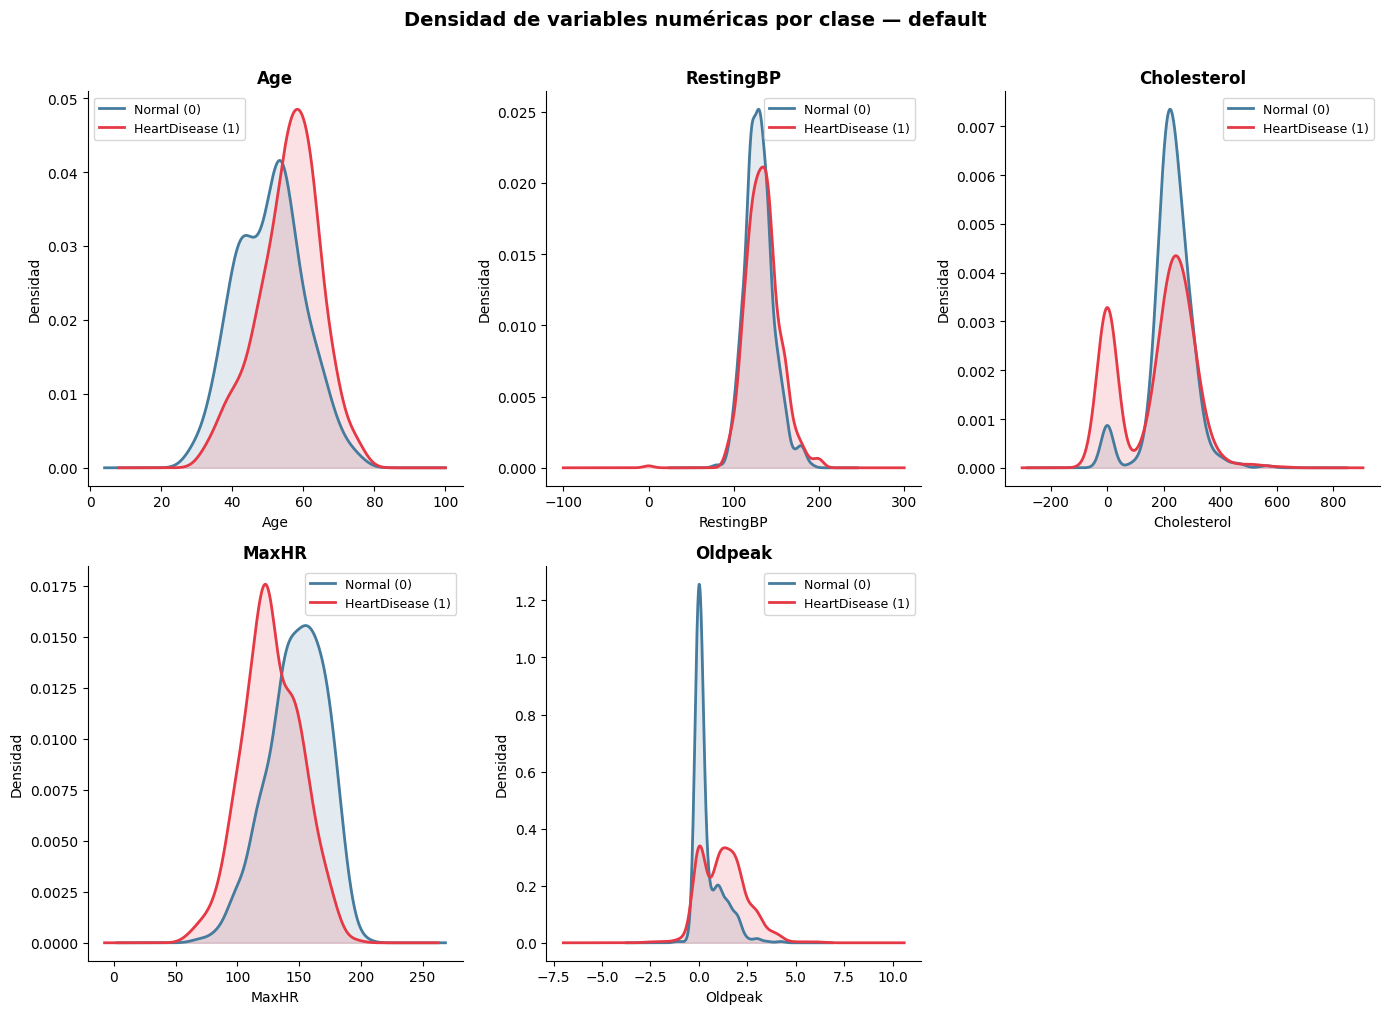

In [27]:
#Variables numéricas: KDE por clase

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
fig.suptitle("Densidad de variables numéricas por clase — default",
             fontsize=14, fontweight="bold", y=1.01)
axes = axes.flatten()

for i, col in enumerate(num_eda):
    ax = axes[i]
    data0 = df[df["HeartDisease"] == 0][col].dropna()
    data1 = df[df["HeartDisease"] == 1][col].dropna()

    data0.plot(kind="kde", ax=ax, color=aqua,   linewidth=2, label="Normal (0)")
    data1.plot(kind="kde", ax=ax, color=morado, linewidth=2, label="HeartDisease (1)")

    ax.fill_between(ax.lines[0].get_xdata(), ax.lines[0].get_ydata(), alpha=0.15, color=aqua)
    ax.fill_between(ax.lines[1].get_xdata(), ax.lines[1].get_ydata(), alpha=0.15, color=morado)

    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

- `Age`: las curvas presentan una separación clara entre grupos. La distribución de edad en pacientes con enfermedad cardíaca tiende a concentrarse en edades más avanzada, con un pico alrededor de los 60 años, mientras que aquellos que no tiene riesgo cardiovascular presentan su pico alrededor de los 55 años. Ambas curvas se solapan considerablemente; sin embargo, la tendencia hacia edades mayores en el grupo enfermo indica una separación evidente.

- `RestingBP`: ambas distribuciones son prácticamente iguales, con picos muy similares cerca de 130 milímetros de mercurio, con un alto grado de solapamiento. Esto confirma lo observado en los boxplot, la presión arterial en reposo tiene poca capacidad discriminatoria entre pacientes sanos y enfermos. 

- `Cholesterol`: la distribución del colesterol muestra un comportamiento distinto entre ambas clases: el grupo de pacientes sin enfermedades cardíacas presenta un pico alrededor de 220 miligramos por decilitro, mientras que el otro grupo, presenta una distribución más dispersa y achatada. Ambos grupos comparten el pico en 0, que corresponde a valores faltantes. Esta mayor dispersión que se encuentra en el grupo de pacientes que tienen enfermedades cardíacas, sugiere una mayor heterogeneidad en los niveles de colesterol de los pacientes.  

- `MaxHR`: esta variable muestra una separación clara entre grupos. Los pacientes sin enfermedades cardíacas presentan su pico de frecuencia cardíaca máxima alcanzada alrededor de 150-160 latidos por minuto, mientras que los pacientes con enfermedades cardíacas lo presentan alrededor de 110-120 latidos por minuto. El solapamiento entre curvas existe, pero es mucho menor que en otras variables, y esto confirma lo visto en el boxplot, la frecuencia cardíaca máxima alcanzada tiene una buena capacidad discriminatoria entre paciente con o sin la enfermedad.

- `Oldpeak`: es una de las variables con mayor separación visual entre grupos. Los pacientes que no tienen enfermedades cardíacas presentan un pico extremadamente pronunciado alrededor de 0, indicando que la mayoría de paciente no presentan una depresión del segmento ST. En contraste, los pacientes con enfermedad cardíaca tienen una distribución más dispersa con valores mucho más altos. Esta diferencia tan marcada, confirma que la variable Oldpeak es una de las variables con mayor poder discriminatorio.

#### **8.4.2 Variables categóricas**

In [28]:
cat_vars = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]

filas = []

for col in cat_vars:
    contingencia = pd.crosstab(df_copia[col], df_copia["HeartDisease"])
    chi2, p_val, dof, _ = chi2_contingency(contingencia)
    n = contingencia.values.sum()
    k = min(contingencia.shape) - 1
    v_cramer = np.sqrt(chi2 / (n * k))

    if v_cramer < 0.1:
        efecto = "Débil"
    elif v_cramer < 0.3:
        efecto = "Moderado"
    elif v_cramer < 0.5:
        efecto = "Fuerte"    
    else:
        efecto = "Muy fuerte"

    tabla_cat = contingencia.copy()
    tabla_cat.columns = ["Normal (0)", "HeartDisease (1)"]
    tabla_cat["Total"] = tabla_cat.sum(axis=1)
    tabla_cat["% Normal"] = (tabla_cat["Normal (0)"] / tabla_cat["Total"] * 100).round(2)
    tabla_cat["% HeartDisease"] = (tabla_cat["HeartDisease (1)"] / tabla_cat["Total"] * 100).round(2)

    categorias = list(tabla_cat.index)

    for i, (categoria, row) in enumerate(tabla_cat.iterrows()):
        filas.append({
            "Variable": col,
            "Categoría": categoria,
            "Normal (0)": int(row["Normal (0)"]),
            "HeartDisease (1)": int(row["HeartDisease (1)"]),
            "Total": int(row["Total"]),
            "% Normal": row["% Normal"],
            "% HeartDisease": row["% HeartDisease"],
            # Solo en la primera categoría de cada variable
            "Chi-cuadrado": round(chi2, 4) if i == 0 else "",
            "p-valor": f"{p_val:.4e}" if i == 0 else "",
            "Significativo": ("Sí" if p_val < 0.05 else "No") if i == 0 else "",
            "V de Cramér": round(v_cramer, 4) if i == 0 else "",
            "Efecto": efecto if i == 0 else ""
        })

df_resultado = pd.DataFrame(filas).set_index(["Variable", "Categoría"])
df_resultado

Normal (0)  HeartDisease (1)  Total  % Normal  \
Variable       Categoría                                                  
Sex            F                 143                50    193     74.09   
               M                 267               458    725     36.83   
ChestPainType  ASY               104               392    496     20.97   
               ATA               149                24    173     86.13   
               NAP               131                72    203     64.53   
               TA                 26                20     46     56.52   
FastingBS      0                 366               338    704     51.99   
               1                  44               170    214     20.56   
RestingECG     LVH                82               106    188     43.62   
               Normal            267               285    552     48.37   
               ST                 61               117    178     34.27   
ExerciseAngina N                 355               192    547     64.90   
               Y                  55               316    371     14.82   
ST_Slope       Down               14                49     63     22.22   
               Flat               79               381    460     17.17   
               Up                317                78    395     80.25   

                          % HeartDisease Chi-cuadrado     p-valor  \
Variable       Categoría                                            
Sex            F                   25.91      84.1451  4.5976e-20   
               M                   63.17                            
ChestPainType  ASY                 79.03     268.0672  8.0837e-58   
               ATA                 13.87                            
               NAP                 35.47                            
               TA                  43.48                            
FastingBS      0                   48.01      64.3207  1.0573e-15   
               1                   79.44                            
RestingECG     LVH                 56.38      10.9315  4.2292e-03   
               Normal              51.63                            
               ST                  65.73                            
ExerciseAngina N                   35.10     222.2594  2.9078e-50   
               Y                   85.18                            
ST_Slope       Down                77.78     355.9184  5.1676e-78   
               Flat                82.83                            
               Up                  19.75                            

                         Significativo V de Cramér      Efecto  
Variable       Categoría                                        
Sex            F                    Sí      0.3028      Fuerte  
               M                                                
ChestPainType  ASY                  Sí      0.5404  Muy fuerte  
               ATA                                              
               NAP                                              
               TA                                               
FastingBS      0                    Sí      0.2647    Moderado  
               1                                                
RestingECG     LVH                  Sí      0.1091    Moderado  
               Normal                                           
               ST                                               
ExerciseAngina N                    Sí       0.492      Fuerte  
               Y                                                
ST_Slope       Down                 Sí      0.6227  Muy fuerte  
               Flat                                             
               Up

Para las variables categóricas se construyo una tabla de contingencia con las frecuencias absolutas y su porcentaje de tener una enfermedad cardíaca. La relación entre variables se evaluó con la prueba Chi-cuadrado, y el tamaño del efecto se cuantificó con la V de Cramér, la cual normaliza el valor de chi-cuadrado, permitiendo comparar relaciones en tablas de cualquier tamaño. Los umbrales utilizados para el estadístico V de Cramer son los siguientes: $V < 0.1$ efecto débil, $1 \leq V < 3$, efecto moderado, $3 \leq V < 5$, efecto fuerte y $V \geq 5$, efecto muy fuerte.

Todas las variables están asociadas significativamente entre ellas (p < 0.05 en todos los casos); no obstante, los tamaños de efecto varían según la variable:

- `Sex`: existe una asociación fuerte (V = 0.30) entre el sexo y la enfermedad cardíaca. Los hombres presentan una tasa de enfermedad del 63.17%, mientras que las mujeres del 25.91%. Es decir, existe una diferencia entre categorías de 38 puntos porcentuales. Esto sugiere que el sexo masculino es un factor de riesgo relevante en el dataset. También puede ser por el muestreo, dado que hay un desbalance entre la cantidad de homnbres y mujeres. 

- `ChestPainType`: es una de las variables con mayor asosiación con la enfermedad cardíaca (V = 0.54). El dolor asintomático es el más preocupante y el que más predomina (79.03%), mientras que el dolor atípico (ATA) es el menos relacionado con un 13.87%. Esto indica que no necesariamente la ausencia de dolor implique que no hay enfermedad, lo que puede complicar a la hora de diagonosticar. 

- `FastingBS`: existe una asociación moderada (V = 0.26) entre la glucosa en ayuna y la enfermedad cardíaca. Se evidencia que los pacientes con azúcar en ayunas elevadas (>120mg/dL) presentan una tasa de enfermedad del 79.44%, frente al 48.01% de aquellos que presentan niveles normales de azúcar. Lo cual tiene sentido, pues aquellos que presenten un nivel de azúcar elevado suelen tener más riesgo de padecer alguna enfermedad cardiovascular. Notemos que la diferencia porcentual entre el grupo de personas con enfermedades cardíacas y azúcar en ayunas elevado se evidencia una diferencia porcentual notable, mientras que aquellas personas que no padecen de ningun riesgo cardiovascular, es casi al azar, es decir, no hay presencia de alguna fuerza de separación entre estas dos clases. Lo que hace que V de Cramer la penalize y el efecto sea moderado.

- `RestingECG`: de la misma manera, existe una asociación moderada (V = 0.11), aunque es la más débil de todas las variables categóricas. Los pacientes con anomalía ST-T presentan la mayor tasa de enfermedad cardíaca (65.73%), frente a aquellos cuyos resultados fueron catalogados como LVH (56.38%) y normales (51.63%). Lo que indica que esta variable discrimina poco entre clases.

- `ExerciseAngina`: presenta una asociación fuerte (V = 0.49), lo que nos da a entender que la presencia de angina inducida por ejercicio esta relacionada con la enfermedad cardíaca. El 85.18% de los pacientes con angina inducida por ejercicio tienen enfermedad cardíaca, en contraste con el 35.10% de pacientes que no la presentan. Esta diferencia tan marcada la convierte en una de las variables más discriminatorias del dataset.

- `ST_Slope`: es la variable categórica con mayor asociación con la enfermedad cardíaca (V = 0.62), concordando con lo analizado anteriormente. Los pacientes con pendiente Flat presentan la mayor tasa de enfermedad (82.83%), seguidos de Down (77.78%), mientras que Up se asocia mayoritariamente con pacientes sanos (80.25%). Esta separación tan clara entre categorías, la posiciona como el predictor categórico más importante del dataset.

En general, todas las variables parecen tener un tamaño de efecto moderado-fuerte, lo que nos da a entender que la mayoría tiene una buena capacidad predictiva, lo cual es beneficioso a la hora de hacer el modelo.

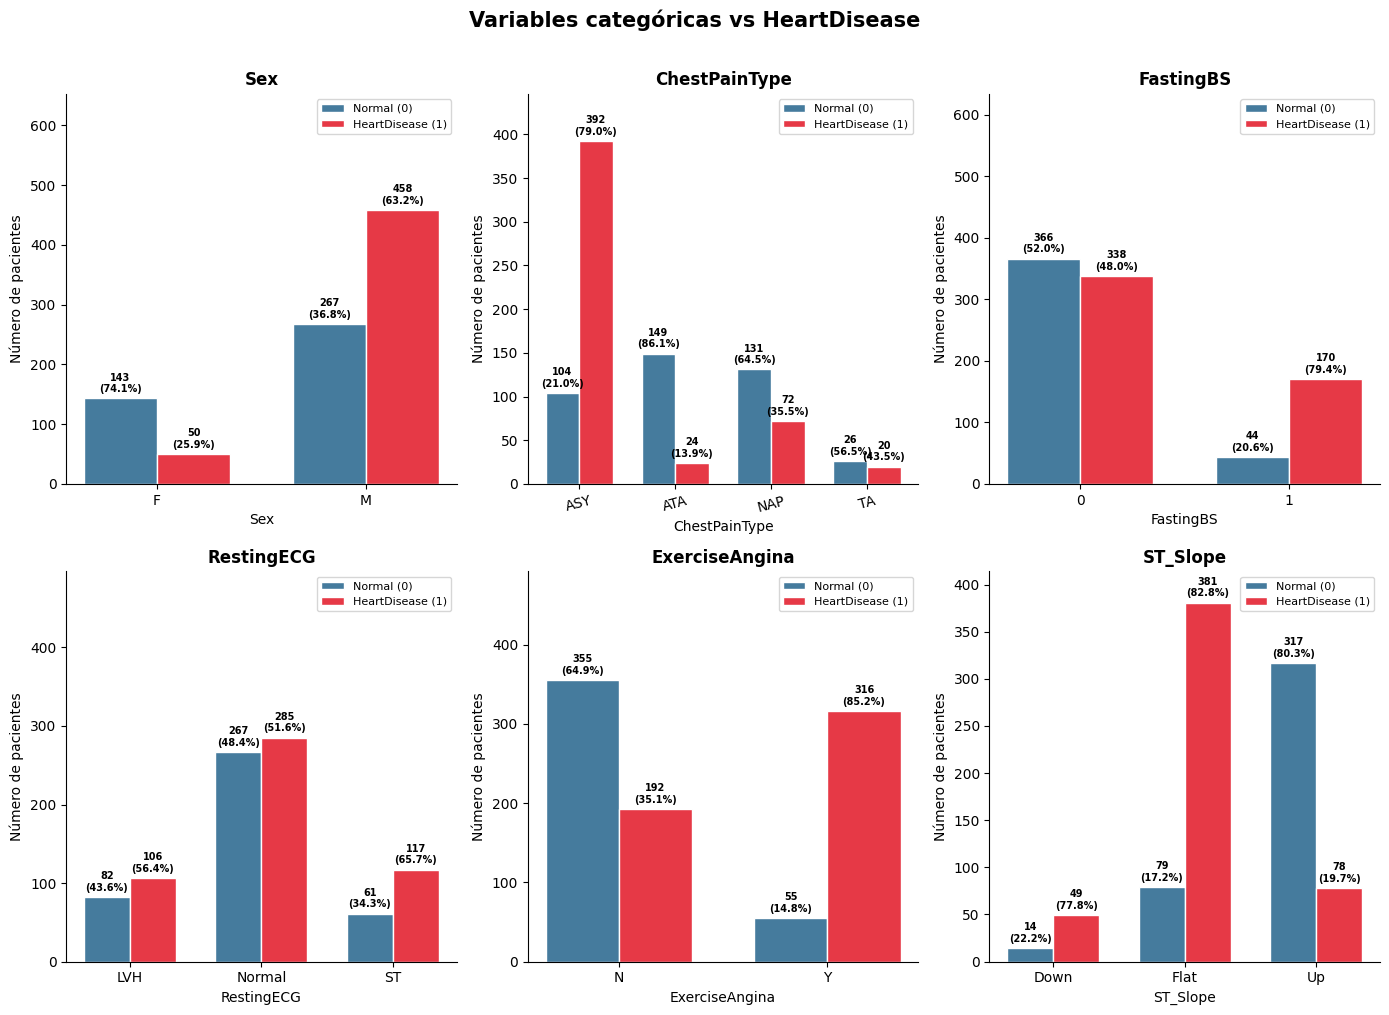

In [29]:
cat_eda = ["Sex", "ChestPainType", "FastingBS",
           "RestingECG", "ExerciseAngina", "ST_Slope"]

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
fig.suptitle("Variables categóricas vs HeartDisease",
             fontsize=15, fontweight="bold", y=1.01)
axes = axes.flatten()

colores = ["#457b9d", "#e63946"]

for i, col in enumerate(cat_eda):
    ax = axes[i]

    tabla = df_copia.groupby([col, "HeartDisease"]).size().unstack(fill_value=0)
    tabla.columns = ["Normal (0)", "HeartDisease (1)"]
    tabla["Total"] = tabla.sum(axis=1)

    categorias = tabla.index
    x = np.arange(len(categorias))
    ancho = 0.35

    bars0 = ax.bar(x - ancho/2, tabla["Normal (0)"], width=ancho,
                   label="Normal (0)", color=colores[0], edgecolor="white")
    bars1 = ax.bar(x + ancho/2, tabla["HeartDisease (1)"], width=ancho,
                   label="HeartDisease (1)", color=colores[1], edgecolor="white")

    for bar, (_, row) in zip(bars0, tabla.iterrows()):
        pct = row["Normal (0)"] / row["Total"] * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + tabla.values.max() * 0.01,
                f"{int(bar.get_height())}\n({pct:.1f}%)",
                ha="center", va="bottom", fontsize=7, fontweight="bold")

    for bar, (_, row) in zip(bars1, tabla.iterrows()):
        pct = row["HeartDisease (1)"] / row["Total"] * 100
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + tabla.values.max() * 0.01,
                f"{int(bar.get_height())}\n({pct:.1f}%)",
                ha="center", va="bottom", fontsize=7, fontweight="bold")

    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Número de pacientes")
    ax.set_xlabel(col)
    ax.set_xticks(x)
    ax.set_xticklabels(categorias, rotation=15 if len(categorias) > 3 else 0)
    ax.set_ylim(0, tabla.values.max() * 0.9)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

- `Sex`: se observa una diferencia marcada entre sexos. La tasa de enfermedad en las mujeres es del 25.9% frente al 63.2% en hombres, es decir, que las mujeres suelen presentar un estado normal (sin enfermedad cardíaca), mientras que en los hombres es lo contrario. Lo que concuerda con lo visto anteriormente. Según estos resultados, ser hombre es un factor de riesgo a la hora de predecir si se va a tener una enfermedad cardíaca. 

- `ChestPainType`: el tipo de dolor ASY (asintomático) domina claramente con un 79% de casos de enfermedad cardíaca, siendo el más asociado a diiagnóstico positivo. En contraste, ATA presenta la mayor proporción de pacientes sanos, con un 86.1% sin enfermedad cardíaca. Por último, el tipo de dolor NAP y TA presentan distribuciones medianamente más equilibradas entre clases. De acuerdo a estos resultados, se evidencia la alta capacidad predictiva de esta variable, marcada por la diferencia entre sus categorías.

- `FastingBS`: cuando el azúcar en ayunas es normal (<120mg/dL), las barras son casi del mismo tamaño, indicando poca capacidad discriminativa en ese grupo. Por otro lado, cuando el azúcar en ayunas es elevado (>120mg/dL), la tasa de enfermedad es del 79.4%, frente al 20.6% sin enfermedad, lo que indica que los pacientes que presentan un nivel de azúcar elevado es un indicador relevante de riesgo cardíaco.

- `RestingECG`: la diferencia entre categorías son moderadas pero consistentes. Los pacientes con resultados normales en el electrocardiograma presentan una tasa de enfermedad del 51.6%, mientras que aquellos que presentaron anomalías en el segmento ST-T cuentan con un 65.7%, y por último aquellos con hipertrofia ventricular izquierda (LVH) presenta una tasa de 56.4%. Se evidencia que, la diferencia entre cada grupo no es prominente, lo que sugiere una capacidad discriminativa limitada, además encaja con lo analizado previamente: es la variable que presento el menor valor en el estadístico V de Cramer.

- `ExerciseAngina`: se observa una diferencia marcada entre aquellos que presentaron angina inducida por ejercicio y los que no. Los pacientes sin angina son mayoritariamente sanos (64.9%), mientras que quienes sí la presentan tienen una tasa de enfermedad del 85.2%. Esto refuerza la capacidad discriminativa de esta variable, indicando que aquellos que muestran angina inducida por ejercicio es un indicio considerable de riesgo cardíaco.

- `ST_Slope`: se observa la relación más clara y consistente del análisis bivariado categórico. Flat predomina con la mayoría de concentración de enfermos (82.8%), Down muestra una tendencia similar aunque con menos volumen (77.8%), y Up presenta una inversión donde la mayoría prelavece en el estado normal (sin enfermedad cardíaca). Este patrón tan definido entre las tres categorías explica su V de Cramér muy fuerte. 

### **8.5 Análisis de correlación**

A continuación, se realizará un análisis de correlación entre las variables numéricas del dataset, con el objetivo de identificar aquellas con mayor capacidad predictiva respecto a la variable objetivo `HeartDisease`, así como detectar posibles relaciones de multicolinealidad entre predictores. Este análisis complementa los resultados obtenidos previamente en las exploraciones univariada y bivariada.

#### **8.5.1 Correlación punto biserial con HeartDisease**

In [30]:
corr_rows = []

for col in num_eda:
    data = df[[col, "HeartDisease"]].dropna()
    corr, p_val = pointbiserialr(data["HeartDisease"], data[col])
    corr_rows.append({
        "Variable":    col,
        "Correlación": round(corr, 4),
        "p-valor":     f"{p_val:.4e}",
        "Significativo (α=0.05)": "Sí" if p_val < 0.05 else "No"
    })

df_corr_biserial = pd.DataFrame(corr_rows).sort_values(
    "Correlación", key=abs, ascending=False
)

df_corr_biserial

,Variable,Correlación,p-valor,Significativo (α=0.05)
4,Oldpeak,0.4040,2.3908e-37,Sí
3,MaxHR,-0.4004,1.1378e-36,Sí
0,Age,0.2820,3.0080e-18,Sí
2,Cholesterol,-0.2327,9.3083e-13,Sí
1,RestingBP,0.1076,1.0953e-03,Sí


El coeficiente de correlación punto biserial es un caso especial de Pearson, y en nuestro caso, examinara la relación entre la variable binaria `HeartDisease` y las variables numéricas. Todos los coeficientes son estadísticamente significativos dado que p < 0.05 para todas las variables.

- `Oldpeak` (r = 0.40): presenta la correlación más alta del grupo. A mayor depresión del segmento ST, mayor probabilidad de enfermedad. Destacando como la variable con mayor poder discriminativo, coherente con su posición en todos los análisis previos.

- `MaxHR` (r = -0.40): correlación negativa moderada. Los pacientes que alcanzan una frecuencia cardíaca máxima durante el esfuerzo baja, suelen presentar mayor probabilidad de enfermedad cardíaca. Reflejando que no necesariamente una frecuencia cardíaca alta implica riesgo cardiovascular.

- `Age` (r = 0.28): correlación positiva débil. Esto implica que, en general, a medida que aumenta la edad, también tiende a aumentar la probabilidad de tener una enfermedad cardíaca levemente. Según resultados anteriores, aunque la edad mostró cierta tendencia en el análisis bivariado, su correlación moderada confirma que es una variable de apoyo más que un predictor dominante.

- `Cholesterol` (r = -0.23): correlación negativa débil. A mayor colesterol, menor probabilidad de enfermedad cardíaca (levemente), lo cual puede estar influenciado por los valores faltantes tratados anteriormente.

- `RestingBP` (r = 0.10): correlación positiva débil. Esto sugiere que, a medida que aumenta la presión arterial en reposo, también tiende a aumentar la probabilidad de tener una enfermedad cardíaca ligeramente. Presentando la correlación más débil, consistente con lo observado en el análisis bivariado.

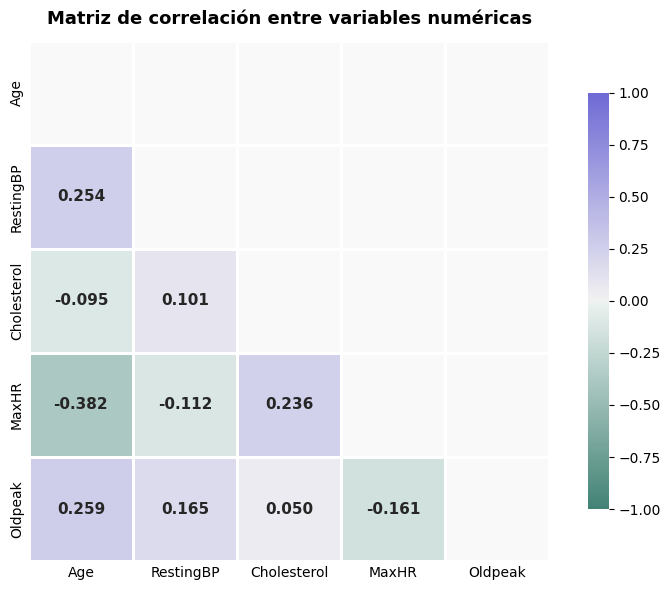


Matriz de correlación:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
Age,1.000000,0.254399,-0.095282,-0.382045,0.258612
RestingBP,0.254399,1.000000,0.100893,-0.112135,0.164803
Cholesterol,-0.095282,0.100893,1.000000,0.235792,0.050148
MaxHR,-0.382045,-0.112135,0.235792,1.000000,-0.160691
Oldpeak,0.258612,0.164803,0.050148,-0.160691,1.000000


In [31]:
#Matriz de correlación entre variables numéricas — Heatmap

corr_matrix = df[num_eda].corr()

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor("#F9F9F9")

cmap = sns.diverging_palette(171, 267, s=70, l=50, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.8,
    linecolor="white",
    square=True,
    ax=ax,
    annot_kws={"size": 11, "weight": "bold"},
    cbar_kws={"shrink": 0.8}
)

ax.set_title("Matriz de correlación entre variables numéricas",
             fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis="both", length=0, labelsize=10)

plt.tight_layout()
plt.show()

print("\nMatriz de correlación:")
corr_matrix

La matriz de correlación de Pearson entre las variables numéricas revela correlaciones bajas en casi todos los pares, destacando:

- `Age` vs `MaxHR` (r = -0.38): es la correlación más alta de la matriz. Los pacientes con edades avanzadas tienden a tener una frecuencia cardíaca máxima baja, lo que tiene sentido ya que la frecuencia cardíaca máxima tiende a disminuir con la edad.

- `Age` vs `Oldpeak` (r = 0.26): correlación positiva débil. A mayor edad, mayor depresión del segmento ST, lo cual concuerda ya que ambas están correlacionadas con la variable respuesta.

- `Cholesterol` presenta correlaciones cercanas a 0 y a 0.2 con todas las demás variables (-0.09, 0.1, 0.2, 0.05), confirmando que es una variable prácticamente independiente del resto en términos lineales.

- El resto de pares presentan correlaciones bajas o muy bajas, lo que indica que las variables aportan información mayormente independiente entre sí.

En general, no se identifican pares de variables con correlación suficientemente alta como para considerar eliminar alguna por redundancia. Es decir, no se presentan problemas de multicolinealidad. La única correlación a considerar es la de `Age` con `MaxHR` (r = -0.38) que aun así está lejos de representar un problema de multicolinealidad para los modelos.

### **8.6 Análisis de multicolinealidad**

Para detallar más de cerca la relación entre las variables predictoras haremos un análisis del VIF

In [32]:
#Evaluación de multicolinealidad — VIF

# Solo variables numéricas sin nulos para VIF
df_vif = df[num_eda].dropna()

X_vif = add_constant(df_vif)

vif_data = pd.DataFrame({
    "Variable": df_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i+1)
            for i in range(len(df_vif.columns))]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

# Interpretación
def clasificar_vif(v):
    if v < 5:
        return "Sin multicolinealidad"
    elif v < 10:
        return "Moderada"
    else:
        return "Severa"

vif_data["Interpretación"] = vif_data["VIF"].apply(clasificar_vif)
vif_data["VIF"] = vif_data["VIF"].round(4)

print("=== Factor de Inflación de la Varianza (VIF) ===\n")
vif_data

=== Factor de Inflación de la Varianza (VIF) ===



,Variable,VIF,Interpretación
0,Age,1.2858,Sin multicolinealidad
1,MaxHR,1.2401,Sin multicolinealidad
2,RestingBP,1.0995,Sin multicolinealidad
3,Oldpeak,1.0963,Sin multicolinealidad
4,Cholesterol,1.0865,Sin multicolinealidad


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


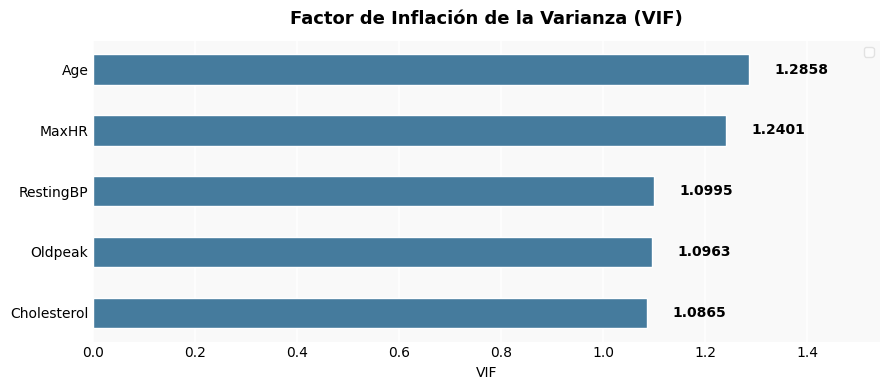

In [33]:
# Gráfico VIF
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_facecolor("#F9F9F9")

colores = [morado if v >= 10 else aqua if v < 5 else "#E8A838"
           for v in vif_data["VIF"]]

bars = ax.barh(vif_data["Variable"], vif_data["VIF"],
               color=colores, edgecolor="white", height=0.5)

for bar, val in zip(bars, vif_data["VIF"]):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", ha="left",
            fontsize=10, fontweight="bold")



ax.set_title("Factor de Inflación de la Varianza (VIF)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("VIF")
ax.set_xlim(0, vif_data["VIF"].max() * 1.2)
ax.xaxis.grid(True, color="white", linewidth=1.2)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.tick_params(axis="both", length=0)
ax.legend(fontsize=9, framealpha=0.5)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

Los resultados del VIF confirman la ausencia total de multicolinealidad entre las variables predictoras. Todos los valores son cercanos a 1, que es el valor mínimo posible e indica que cada variable es independiente de las demás por términos lineales:

- `Age` (VIF = 1.28) y `MaxHR` (VIF = 1.24): presentan los valores más altos del grupo, consistente con su correlación de Pearson de -0.38 observada previamente. Sin embargo, ambos están muy por debajo del umbral de 5, confirmando que dicha correlación no introduce redundancia problemática.

- `RestingBP` (VIF = 1.09), `Oldpeak` (VIF = 1.09) y `Cholesterol` (VIF = 1.08): presentan los valores prácticamente iguales a 1, lo que indica que son variables ortogonales al resto, sin ningún grado de redundancia lineal con las demás.

La diferencia entre todos los VIF es mínima (rango de apenas 0.1993 entre el mayor y el menor), lo que refleja un conjunto de variables numéricas con estructura de dependencia muy baja. Este resultado es coherente con los valores observados en la matriz de correlación y refuerza la calidad del subconjunto de predictores.

## **9. Preprocesamiento y Detección de Data Leakage (Etapa 1)**

Para esta sección, se hará uso de `Pipelines` sencillos con la finalidad de demostrar el peligro del data leakage, en donde se empleará un ejemplo donde hay fuga de datos con el modelo de clasificador de soporte vectorial (SVC) junto con otros modelos sin data leakage que hemos dado en clase. Para esto, se utilizaran funciones reutilizables que harán más sencillo el proceso. Al final, se hará una tabla comparativa contrastando cada modelo y evaluando la importancia de evitar la fuga de datos, para la comparación de resultados, se utilizará la métrica AUC y Acurracy. 

Primero, mostraremos las funciones reutilizables que utilizaremos durante todo este proceso:

In [34]:
# -------------- FUNCIONES REUTILIZABLES --------------
# creamos función para facilitar el entrenamiento de cada modelo
def train_pipeline(transformacion, X_train, y_train, model, param_grid):
    
    if transformacion is None:   
        pipe = Pipeline([("clf", model)])
    else:
        pipe = Pipeline([
            ("preprocessor", transformacion),
            ("clf", model)
        ])
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc")
    grid.fit(X_train, y_train)
    return grid


def evaluar_modelo(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)
    auc_VC = modelo.best_score_
    mejores_parametros = modelo.best_params_
    
    return auc, accuracy, auc_VC, mejores_parametros


def entrenamiento_modelo(transformacion, modelos, X_train, y_train, X_test, y_test):
    resultados = []
    grids_entrenados = {}
    
    for name, (model, params) in modelos.items():
        grid = train_pipeline(transformacion, X_train, y_train, model, params)
        grids_entrenados[name] = grid
        
        auc, acc, auc_VC, mejores_parametros = evaluar_modelo(grid, X_test, y_test)
        
        resultados.append([name, auc, acc, auc_VC, mejores_parametros])
    
    return pd.DataFrame(resultados, columns=["Modelo", "AUC", "Accuracy", "AUC VC", "Mejores parametros"]), grids_entrenados      


# definimos los modelos a utilizar con su param grid 
modelos = {
    "SVC": (
        SVC(probability=True),
        {"clf__C": [0.1, 1, 10], "clf__gamma": [0.01, 0.1]}
    ),
    "LogisticRegression": (
        LogisticRegression(max_iter=1000),
        {"clf__C": [0.1, 1, 10]}
    ),
    "RandomForest": (
        RandomForestClassifier(),
        {"clf__n_estimators": [100, 200], "clf__max_depth":[None, 5, 10]}
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"clf__n_neighbors": [3, 5, 7]}
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(),
        {"clf__n_estimators": [100, 200], "clf__learning_rate":[0.01, 0.1]}
    )
}

Cabe añadir, que gracias al EDA sabemos que hay valores a imputar en la variable `Cholesterol`, por lo que se decidió imoputarlos a través de la mediana. 

In [35]:
# -------------- ########### --------------
df["FastingBS"] = df["FastingBS"].astype("object") #convertimos a 'FastingBS' catalogada como numérica a categórica.


# separamos en variables predictoras y variable objetivo
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]


# -------------- PRIMERA FUGA DE DATOS --------------
# primera tipo de fuga de datos - Creamos variable leaky que sale de la variable objetivo.
np.random.seed(0)
X_con_leaky = X.copy() # copiamos el dataframe X para no dañar el original

leaky_feature = y + np.random.normal(0, 0.01, size=len(y))
X_con_leaky["leaky_feature"] = leaky_feature

# -------------- SEGUNDA FUGA --------------
# Ejemplo con fuga de datos (data leakage)

# primero dividimos en categóricas y numéricas
cat_cols = X_con_leaky.select_dtypes(include="object").columns
num_cols = X_con_leaky.select_dtypes(exclude="object").columns

# creamos el preprocesador
preprocessor_leaky = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop="first", handle_unknown='ignore'), cat_cols),
    ("num", Pipeline([
        ("imputer", SimpleImputer(missing_values=0, strategy="median")),
        ("scaler", MinMaxScaler())
    ]), num_cols)
])

# segunda tipo de fuga de datos - Escalar antes de dividr
X_scaled_leaky = preprocessor_leaky.fit_transform(X_con_leaky)

# dividimos los datos
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_scaled_leaky, y, test_size=0.2, random_state=42)

# le pasamos el modelo con fuga
modelo_fuga = {
    "SVC con fuga": (
        SVC(probability=True),
        {"clf__C": [0.1, 1, 10], "clf__gamma": [0.01, 0.1]}
    )
}

# llamamos a la función reutilizable
transformacion=None
resultados_l, grids = entrenamiento_modelo(transformacion, modelo_fuga, X_train_l, y_train_l, X_test_l, y_test_l)

In [36]:
# -------------- SIN FUGA --------------

# MANERA CORRECTA - Primero dividimos antes de escalar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Ahora si, hacemos todo el proceso de preprocesamiento después de dividir los datos
cat_cols_sin = X_train.select_dtypes(include="object").columns
num_cols_sin = X_train.select_dtypes(exclude="object").columns

preprocessor_sin_fuga = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop="first", handle_unknown='ignore'), cat_cols_sin),
    ("num", Pipeline([
        ("imputer", SimpleImputer(missing_values=0, strategy="median")),
        ("scaler", MinMaxScaler())
    ]), num_cols_sin)
])

transformacion=preprocessor_sin_fuga
tabla_comparativa, grids = entrenamiento_modelo(transformacion, modelos, X_train, y_train, X_test, y_test)

# -------------- RESULTADOS --------------
tabla_comparativa = pd.concat([resultados_l, tabla_comparativa], ignore_index=True)
tabla_comparativa[["Modelo", "AUC", "Accuracy", "AUC VC"]]
tabla_comparativa = tabla_comparativa.sort_values("AUC", ascending=False).reset_index(drop=True)
tabla_comparativa[["Modelo", "AUC", "Accuracy", "AUC VC"]]

,Modelo,AUC,Accuracy,AUC VC
0,SVC con fuga,1.000000,1.000000,1.000000
1,RandomForest,0.935916,0.891304,0.926976
2,SVC,0.933525,0.858696,0.917403
3,LogisticRegression,0.931253,0.885870,0.919121
4,KNN,0.923063,0.880435,0.894158
5,GradientBoosting,0.920612,0.858696,0.922721


La tabla anterior, se compone del resultado de los entrenamientos donde hubo fuga de datos y otro en el que no. Cabe aclarar, que el único modelo que se entreno con fuga de datos fue el SVC, que se encuentra en la tabla como `SVC con fuga`. Los otros modelos presentados, que se encuentran desde la fila 1 hasta la 5, fueron entrenados de la manera correcta, es decir, dividiendo antes de hacer el escalado, lo que evitó el data leakage.

A simple el vista, el modelo con mayor AUC y accuracy fue el entrenado mediante SVC con fuga de datos, puesto que presentó un score en las métricas de 1, esto nos da entender, que es un modelo perfecto, que no se equivoca. Esto se debe a dos factores: primero, el escalado con `MinMaxScaler` fue aplicado antes de la división, permitiendo que el modelo conociera el mínimo y máximo global del dataset incluyendo los datos de prueba. Segundo, la variable `leaky_feature` fue construida directamente a partir de la variable objetivo, por lo que el modelo prácticamente memorizó las etiquetas en lugar de aprender patrones reales. Por lo tanto, ese score tan sobresaliente, es un engaño, ya que al modelo a acceder a los datos de prueba y usarlos antes de entrenar le otorga una ventaja.

Por otro lado, el modelo con mayor AUC fue `RandomForest` (0.9359), seguido de cerca por `SVC` (0.9335) y `LogisticRegression` (0.9312), mientras que `KNN` y `GradientBoosting` de 0.92. En contraste, en el `accuracy` también lidero el modelo de RandomForest con un score de 0.89; sin embargo, tampoco es tanta la diferencia con el puntaje más bajo ya que es solo de 0.03 puntos porcentuales; estos resultados obtenidos mediante el uso de Pipeline son mucho más coherentes y confiables que los obtenidos cuando hubo fugo de datos. Es importante recalcar que, aunque en ambos se realizo SVC, en uno dio puntaje perfecto y en el otro no, aquí nos damos cuenta de la importancia de dividir antes de escalar los datos, ya que de esa manera el modelo no se infiltra de manera indirecta en los datos, haciendo del modelado un proceso engañoso. 